# Complete Chess Analysis

**A full analytics report over my Chess.com game history.**

This notebook is a showcase of the whole `Chess-Project` analytics pipeline: it
downloads/loads a player's Chess.com games, parses the PGNs, runs (cached)
Stockfish evaluations, and turns the result into statistics, plots, and
heuristic "player style" insights.

## What data is analyzed

- **Source**: every rated and casual game played by the configured Chess.com
  username (`config.MY_CHESS_USERNAME`), downloaded via the Chess.com public API.
- **Granularity**: one row per game (`games_df`), one row per half-move / ply
  (`moves_df`), and one row per analyzed ply with an engine evaluation
  (`result_df`).
- **Engine data**: centipawn evaluations at a fixed search depth (10), computed
  once and cached to disk (`data/processed/evaluation_cache/`) so re-running
  this notebook doesn't require re-analyzing anything that's already cached.

## The pipeline

```
Chess.com API  ──►  raw PGN/JSON  ──►  games_df / moves_df  ──►  Stockfish (cached)
     │                                        │                        │
     ▼                                        ▼                        ▼
download_chess_games()          process_and_save_chess_data()   run_chess_analysis()
                                                                          │
                                                                          ▼
                                                                     result_df
                                                                          │
                        ┌─────────────────────────┬──────────────────────┼───────────────────┐
                        ▼                         ▼                      ▼                    ▼
              General statistics        Opening analysis        Tactical analysis     Player style analysis
```

## Limitations (read this first)

- **Engine depth is shallow (10 ply)** for speed/caching reasons — evaluations
  are indicative, not tournament-grade analysis.
- **"Brilliant move" and "sacrifice" detection are heuristics** based on
  same-square capture/recapture patterns from the moves actually played, not a
  full search of alternatives. They will miss some genuine brilliancies and
  occasionally flag ordinary tactics.
- **Chess.com's own accuracy % is only available for some games** (mostly
  rapid/blitz; rarely for bullet), so the accuracy trend chart uses a smaller
  sample than the full game count.
- **"Player style" features are exploratory**, not a validated psychometric
  model — treat them as a readable summary of tendencies already visible in
  the other charts, not a scientific classification.
- All numbers reflect only the games present in the local dataset at the time
  this notebook was run.

In [1]:
# ---------------------------------------------------------------------------
# Setup
# ---------------------------------------------------------------------------
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

from config import *

warnings.filterwarnings("ignore", category=UserWarning, module="matplotlib")
plt.rcParams["figure.facecolor"] = "white"
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 140)

print(f"Analyzing Chess.com user: {MY_CHESS_USERNAME}")
print(f"Stockfish available on this machine: {STOCKFISH_AVAILABLE}")

Analyzing Chess.com user: ParpasP
Stockfish available on this machine: False


## 1. Data Loading

Load (or download, if this is the first run) this player's games, parse them
into tidy dataframes, and run the cached engine analysis.

In [2]:
from src.download_save_load import get_chess_dataframes

games_df, moves_df = get_chess_dataframes(username=MY_CHESS_USERNAME, format="csv")

print(f"\nGames: {len(games_df):,}   Moves: {len(moves_df):,}")
print(f"Date range: {games_df['Time'].min()}  -  {games_df['Time'].max()}")
games_df.head(3)

⚠️ No USER_AGENT set in .env — using a generic default. Chess.com's API asks that requests identify a contact; consider adding USER_AGENT to a .env file.
🔍 Looking for existing dataframes for ParpasP...


✓ Loaded 2379 games and 148539 moves from csv files

Games: 2,379   Moves: 148,539
Date range: 2024-11-26 19:16:25+00:00  -  2026-04-22 09:07:40+00:00


,uuid,link_id,link,time_class,time_control,rated,white,white_rating,black,black_rating,rating_diff,opening,simple_opening,eco_code,my_color,result,white_accuracy,black_accuracy,Time,end_time,moves
0,71ba5026-3e2a-11f1-a0f1-86ad2101000f,167657102686,https://www.chess.com/game/live/167657102686,bullet,60+1,True,ParpasP,877,Anurag7381,782,95,Queens-Pawn-Opening-Mikenas-Defense-2.c4-e5,Quenn's Pawn Opening,A40,White,Win,NaN,NaN,2026-04-22 09:07:40+00:00,1776848860,d4|e5|c4|Nc6|dxe5|Nxe5|Nf3|Nxc4|Nc3|Bb4|e4|Bxc...
1,2373403c-3e2a-11f1-8849-28ad8d01000f,167657034790,https://www.chess.com/game/live/167657034790,bullet,60+1,True,donut1,870,ParpasP,871,-1,Closed-Sicilian-Defense-2...e6-3.d3,Closed Sicilian Defense,B23,Black,Win,NaN,NaN,2026-04-22 09:05:35+00:00,1776848735,e4|c5|Nc3|e6|d3|d5|exd5|exd5|Nf3|d4|Ne4|Nc6|Be...
2,b9037a8d-3e29-11f1-8849-28ad8d01000f,167656944644,https://www.chess.com/game/live/167656944644,bullet,60+1,True,ParpasP,863,Roszek8,879,-16,Queens-Gambit-Declined-Baltic-Deferred-Queen-A...,Queen's Gambit Declined,D06,White,Loss,NaN,NaN,2026-04-22 09:03:29+00:00,1776848609,d4|d5|c4|Bf5|Nc3|e6|Qb3|b6|e3|Nf6|Be2|Be7|Nf3|...


In [3]:
from src.cache import run_chess_analysis

# Uses the on-disk evaluation cache — no live Stockfish engine required as
# long as every move here was already analyzed at >= depth 10 previously.
# This can take a minute or two the first time; it's instant on re-runs.
result_df, moves_df = run_chess_analysis(
    games_df, moves_df, time_control=None, n_games=-1, depth=10, use_cache=True
)
result_df.head(3)

✅ Games selected: 2379
✅ Moves selected: 148539


Loaded 148539 cached evaluations


Analyzing moves:   0%|          | 0/148539 [00:00<?, ?move/s]

💾 Saved 148539 evaluations to cache                               



Total moves analyzed: 148539
Games analyzed: 2377
Cache hits: 148539
New evaluations: 0
Cache size: 148539 total entries


,link_id,uuid,move_index,move_no,player,move,my_move,eval_before,eval_after,delta,blunder,blunder_type,move_type,fen,end_time
68154,167657102686,71ba5026-3e2a-11f1-a0f1-86ad2101000f,0,1,white,d4,True,0,28,28,False,no_blunder,Best,rnbqkbnr/pppppppp/8/8/3P4/8/PPP1PPPP/RNBQKBNR ...,1776848860
68155,167657102686,71ba5026-3e2a-11f1-a0f1-86ad2101000f,1,1,black,e5,False,28,116,-88,False,no_blunder,Inaccuracy,rnbqkbnr/pppp1ppp/8/4p3/3P4/8/PPP1PPPP/RNBQKBN...,1776848860
68156,167657102686,71ba5026-3e2a-11f1-a0f1-86ad2101000f,2,2,white,c4,True,116,-47,-163,False,no_blunder,Mistake,rnbqkbnr/pppp1ppp/8/4p3/2PP4/8/PP2PPPP/RNBQKBN...,1776848860


## 2. General Statistics

Overall results, rating progression, time controls, and playing habits.

In [4]:
n_games = games_df["uuid"].nunique()
result_counts = games_df["result"].value_counts()
result_pct = (result_counts / n_games * 100).round(1)

print(f"Total games: {n_games:,}")
print(f"Date range:  {games_df['Time'].min().date()}  to  {games_df['Time'].max().date()}")
print()
print("Result breakdown:")
for r in ["Win", "Loss", "Draw"]:
    print(f"  {r:5s}: {result_counts.get(r, 0):4d}  ({result_pct.get(r, 0.0)}%)")

Total games: 2,379
Date range:  2024-11-26  to  2026-04-22

Result breakdown:
  Win  : 1308  (55.0%)
  Loss : 1025  (43.1%)
  Draw :   46  (1.9%)


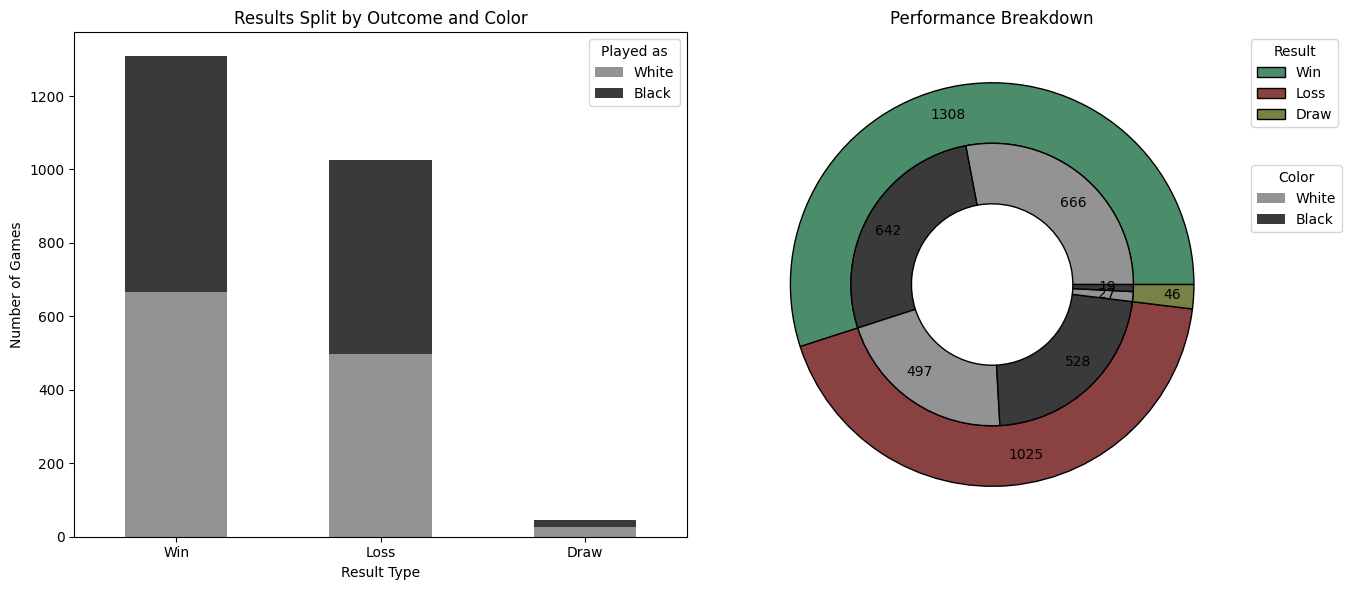

In [5]:
from src.statistics import plot_game_results

plot_game_results(games_df)

In [6]:
# White vs Black performance
white_black = (
    games_df.groupby("my_color")["result"]
    .value_counts(normalize=True)
    .mul(100)
    .round(1)
    .unstack()
    .reindex(columns=["Win", "Draw", "Loss"])
)
white_black

result,Win,Draw,Loss
my_color,,,
Black,54.0,1.6,44.4
White,56.0,2.3,41.8


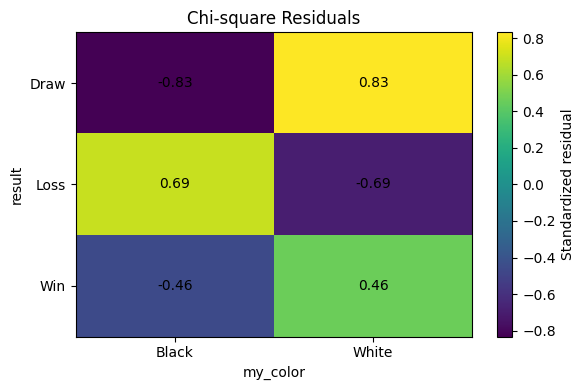

No statistically significant association (p = 0.2505). No evidence of dependence between variables.


,Statistic,Value
0,Chi-square,2.768800
1,p-value,0.250472
2,Degrees of freedom,2.000000
3,Sample size,2379.000000


In [7]:
from src.statistics import chi_square_analysis

summary_df, interpretation = chi_square_analysis(games_df)
print(interpretation)
summary_df

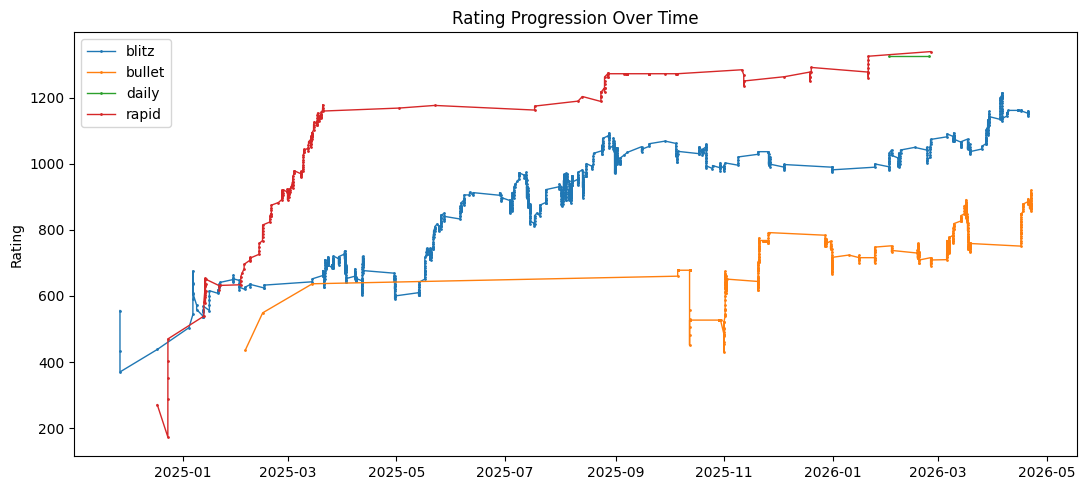

In [8]:
from src.overview_stats import plot_rating_progression

plot_rating_progression(games_df)

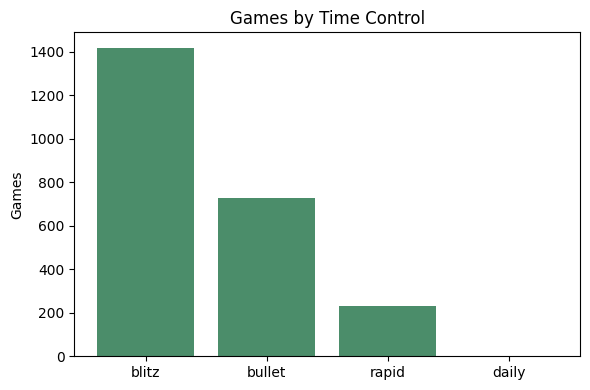

In [9]:
from src.overview_stats import plot_time_control_distribution

plot_time_control_distribution(games_df)

In [10]:
from src.player_profile import game_length_stats

game_length_stats(games_df, moves_df)

,games,avg_full_moves,median_full_moves
result,,,
Draw,46,45.858696,42.0
Loss,1025,31.692683,29.5
Win,1308,30.379020,27.5


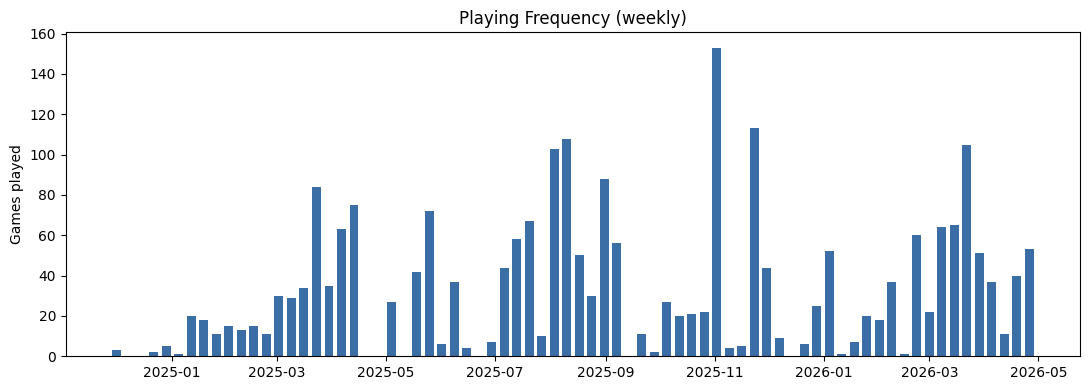

In [11]:
from src.overview_stats import plot_playing_frequency

plot_playing_frequency(games_df, freq="W")

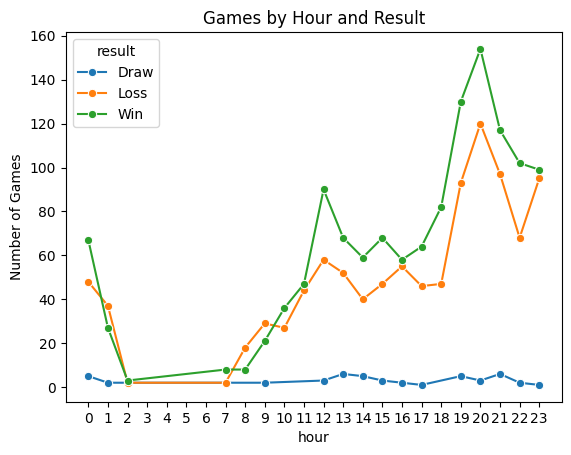

In [12]:
from src.statistics import daytime

daytime(games_df)

## 3. Opening Analysis

Repertoire breadth, performance by opening, ECO family classification, and
how the repertoire has evolved over time.

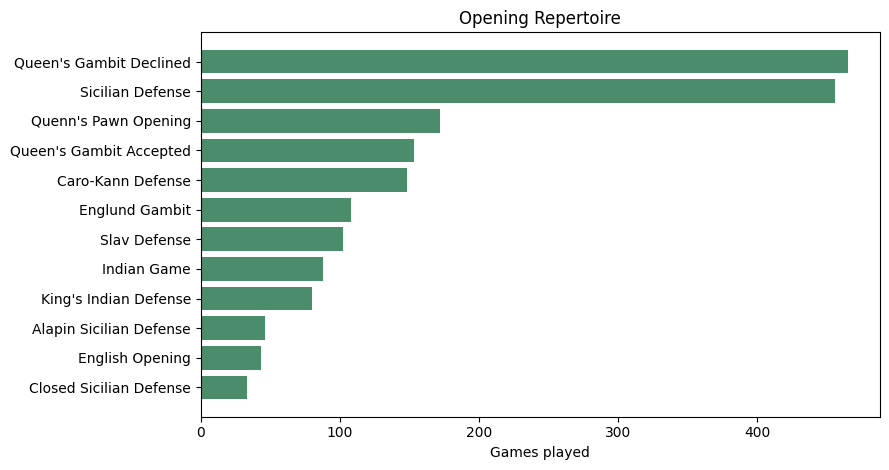

,games,wins,draws,losses,win_pct,draw_pct,loss_pct,avg_score,first_played,last_played
simple_opening,,,,,,,,,,
Queen's Gambit Declined,465,268,11,186,57.634409,2.365591,40.000000,0.588172,2025-01-12 14:55:27+00:00,2026-04-22 09:03:29+00:00
Sicilian Defense,456,238,4,214,52.192982,0.877193,46.929825,0.526316,2025-02-07 22:41:49+00:00,2026-04-22 07:53:41+00:00
Quenn's Pawn Opening,172,96,5,71,55.813953,2.906977,41.279070,0.572674,2025-01-08 20:31:31+00:00,2026-04-22 09:07:40+00:00
Queen's Gambit Accepted,153,84,2,67,54.901961,1.307190,43.790850,0.555556,2025-02-12 22:00:46+00:00,2026-04-20 14:06:27+00:00
Caro-Kann Defense,148,82,2,64,55.405405,1.351351,43.243243,0.560811,2025-01-13 15:06:04+00:00,2025-07-04 20:25:19+00:00
Englund Gambit,108,69,2,37,63.888889,1.851852,34.259259,0.648148,2025-01-06 20:53:11+00:00,2026-04-22 07:59:20+00:00
Slav Defense,102,56,2,44,54.901961,1.960784,43.137255,0.558824,2025-02-19 12:46:27+00:00,2026-04-22 08:03:02+00:00
Indian Game,88,50,0,38,56.818182,0.000000,43.181818,0.568182,2025-03-22 16:33:24+00:00,2026-04-20 14:54:56+00:00
King's Indian Defense,80,30,1,49,37.500000,1.250000,61.250000,0.381250,2025-02-25 18:05:43+00:00,2026-04-21 08:53:26+00:00


In [13]:
from src.opening_analysis import opening_repertoire, plot_opening_repertoire

plot_opening_repertoire(games_df, top_n=12)
opening_repertoire(games_df, min_games=5).head(15)

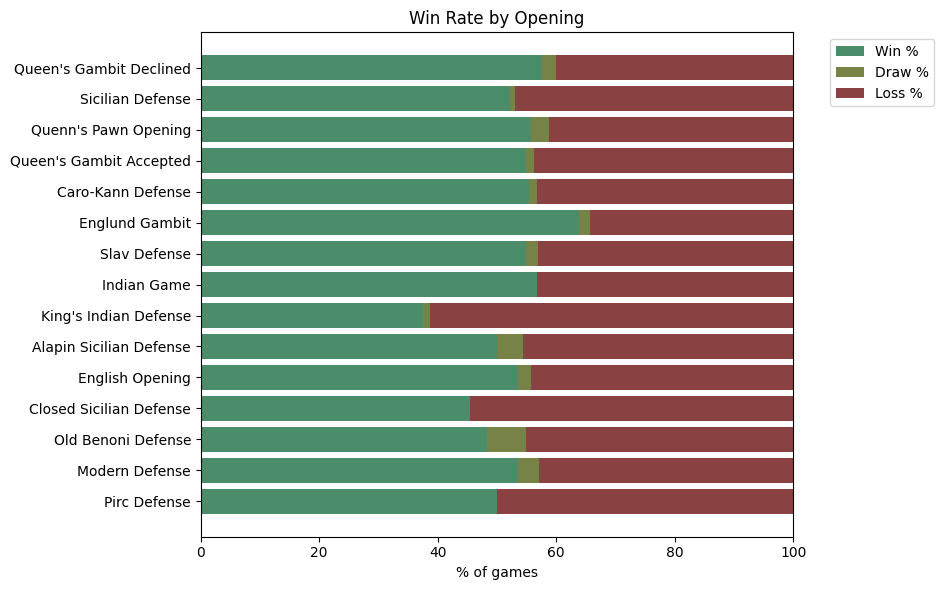

In [14]:
from src.opening_analysis import plot_win_rate_by_opening

plot_win_rate_by_opening(games_df, min_games=8, top_n=15)

In [15]:
from src.opening_analysis import best_worst_openings

best, worst = best_worst_openings(games_df, min_games=10, top_n=8)
print("Best-performing openings (min. 10 games):")
display(best[["games", "win_pct", "avg_score"]])
print("\nWorst-performing openings (min. 10 games):")
display(worst[["games", "win_pct", "avg_score"]])

Best-performing openings (min. 10 games):


,games,win_pct,avg_score
simple_opening,,,
London System,17,82.352941,0.823529
Giuco Piano,11,81.818182,0.818182
French Defense,18,72.222222,0.722222
Scotch Game,14,71.428571,0.714286
Scandinavian Defense,16,68.750000,0.687500
King's Pawn Opening,19,68.421053,0.684211
Englund Gambit,108,63.888889,0.648148
Reti Opening,16,62.500000,0.625000



Worst-performing openings (min. 10 games):


,games,win_pct,avg_score
simple_opening,,,
Queens Gambit,14,35.714286,0.428571
King's Indian Defense,80,37.500000,0.381250
Colle System,12,41.666667,0.416667
Van't Kruijs,18,44.444444,0.527778
Closed Sicilian Defense,33,45.454545,0.454545
Mieses Opening,13,46.153846,0.461538
Old Benoni Defense,31,48.387097,0.516129
King's Fianchetto,12,50.000000,0.500000


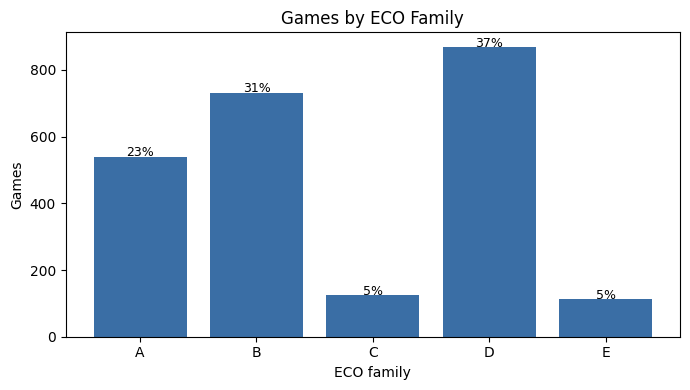

In [16]:
from src.opening_analysis import plot_eco_family_distribution

plot_eco_family_distribution(games_df)

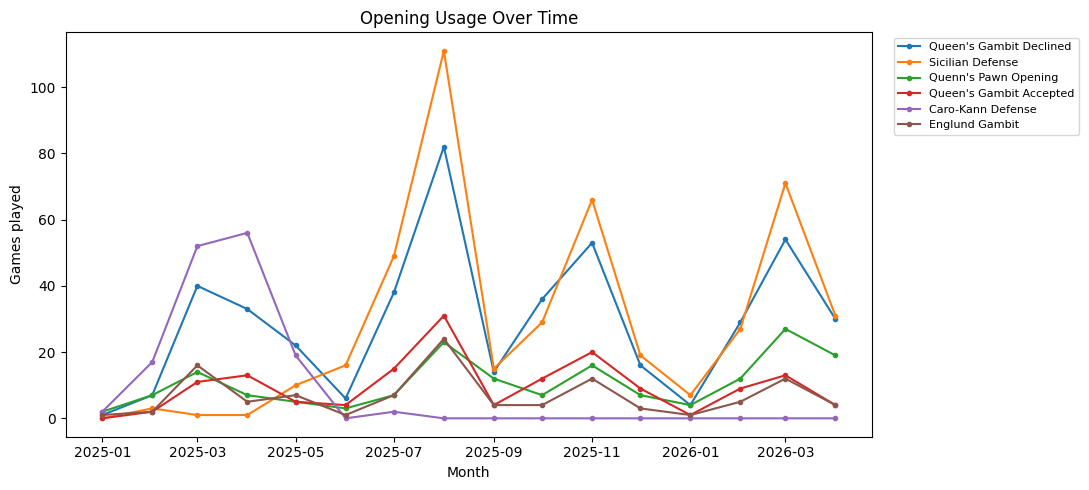

In [17]:
from src.opening_analysis import plot_opening_trend

plot_opening_trend(games_df, top_n=6)

In [18]:
from src.opening_analysis import opening_diversity_index

overall = opening_diversity_index(games_df)
as_white = opening_diversity_index(games_df, color="White")
as_black = opening_diversity_index(games_df, color="Black")

print("Opening repertoire diversity (Shannon-entropy based):")
for label, d in [("Overall", overall), ("As White", as_white), ("As Black", as_black)]:
    print(f"  {label:10s}: {d['n_distinct_openings']:3d} distinct openings, "
          f"effective repertoire ~{d['effective_repertoire']:.1f}, "
          f"normalized diversity {d['normalized_entropy']:.2f}")

Opening repertoire diversity (Shannon-entropy based):
  Overall   :  68 distinct openings, effective repertoire ~19.7, normalized diversity 0.71
  As White  :  50 distinct openings, effective repertoire ~12.1, normalized diversity 0.64
  As Black  :  55 distinct openings, effective repertoire ~14.2, normalized diversity 0.66


## 4. Tactical Analysis

Blunders, mistakes, accuracy trends, and a heuristic "brilliant move" detector,
all computed from the cached Stockfish evaluations in `result_df`.

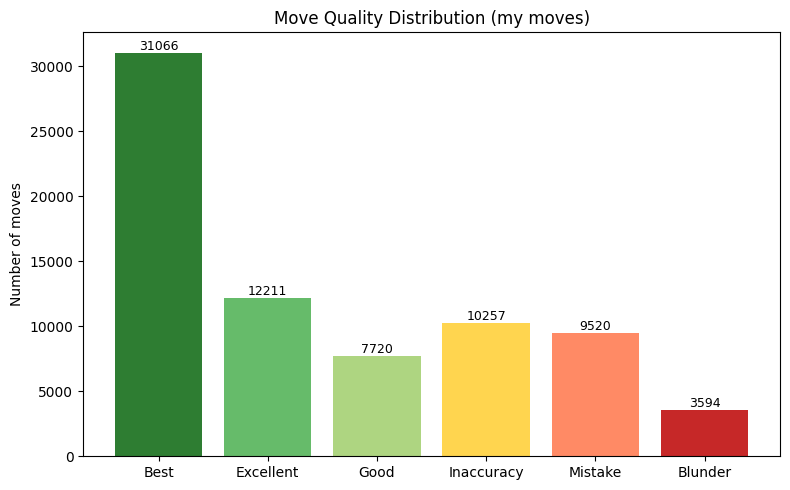

In [19]:
from src.tactics_analysis import plot_move_quality_distribution

plot_move_quality_distribution(result_df)

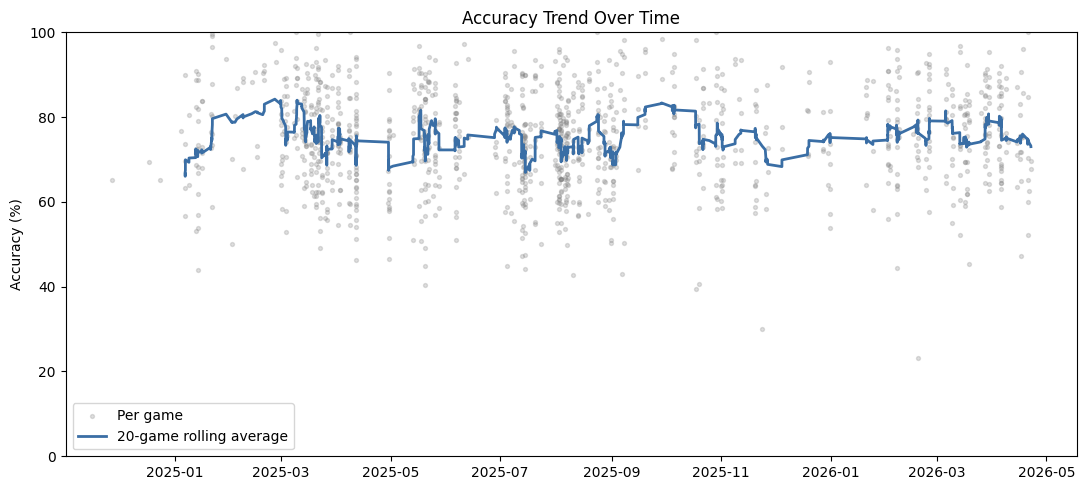

In [20]:
from src.tactics_analysis import plot_accuracy_trend

plot_accuracy_trend(games_df, rolling_window=20)

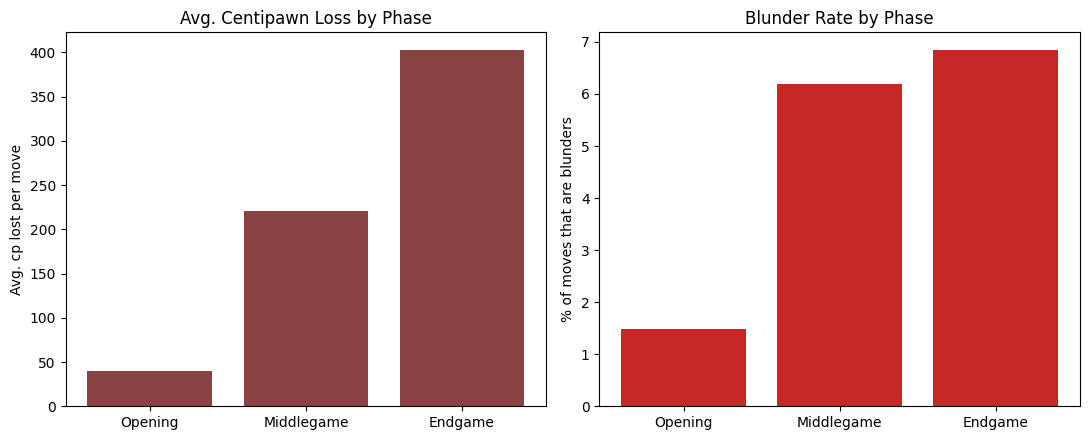

In [21]:
from src.tactics_analysis import plot_eval_loss_by_phase

plot_eval_loss_by_phase(result_df)

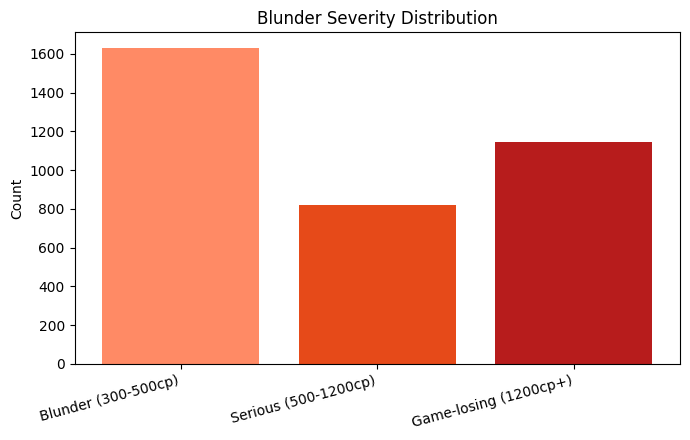

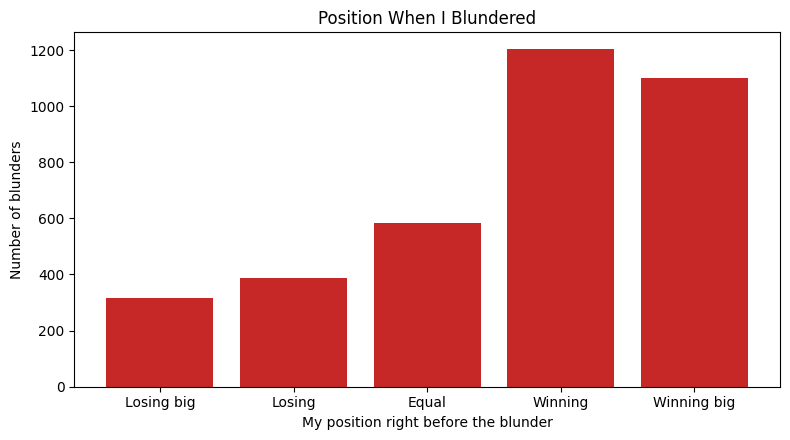

In [22]:
from src.tactics_analysis import plot_blunder_severity, plot_game_state_when_blundered

plot_blunder_severity(result_df)
plot_game_state_when_blundered(result_df)

In [23]:
# Note: evals of +-10000 are a "forced mate" sentinel, not literal centipawns
# (see src.cache.evaluate) - worst_mistakes() renders these as "Mate" rather
# than a misleading six-figure centipawn swing.
from src.tactics_analysis import worst_mistakes

worst_mistakes(result_df, games_df, n=10)

,uuid,link_id,move_no,player,move,eval_before_display,eval_after_display,cp_loss,move_type,simple_opening,result,time_class
0,24347edf-e334-11f0-9c69-fb411201000f,147243903576,22,white,Ne2,Mate (for White),Mate (for Black),20000,Blunder,Queen's Gambit Accepted,Loss,bullet
1,50ea4869-5f7c-11f0-91b1-f23cba01000f,140631019728,27,black,Kxh7,Mate (for Black),Mate (for White),20000,Blunder,Sicilian Defense,Loss,blitz
2,c80f58ad-8744-11f0-9cc8-0b52fe01000f,142599589704,37,black,Rf7,Mate (for Black),Mate (for White),20000,Blunder,Indian Game,Loss,blitz
3,742acc32-7166-11f0-933f-66d1e001000f,141487991726,30,black,Bc7,Mate (for Black),Mate (for White),20000,Blunder,Sicilian Defense,Loss,blitz
4,04154dea-70b2-11f0-8fff-9244c801000f,141453517010,36,black,e1=Q,Mate (for Black),Mate (for White),20000,Blunder,Sicilian Defense,Loss,blitz
5,4b5c2320-34e5-11f0-8a74-db8de801000f,138640588856,29,black,Rb5,Mate (for Black),Mate (for White),20000,Blunder,Caro-Kann Defense,Loss,blitz
6,2711d4be-c59e-11f0-ba11-748b1e01000f,145720527724,27,black,Be2,Mate (for Black),Mate (for White),20000,Blunder,Quenn's Pawn Opening,Win,bullet
7,89de6378-f60f-11ef-b71b-06a70501000f,123401245068,30,white,Qxh8,+10.23,Mate (for Black),11023,Blunder,Quenn's Pawn Opening,Loss,rapid
8,458d637d-f24e-11f0-8edc-c6744601000f,148057650660,23,black,Re6,-8.08,Mate (for White),10808,Blunder,Sicilian Defense,Loss,bullet
9,ce6e019b-b44e-11f0-a829-974a0401000f,144851805206,30,white,Re1,+7.93,Mate (for Black),10793,Blunder,Queen's Gambit Accepted,Loss,bullet


In [24]:
from src.tactics_analysis import conversion_collapse

collapse = conversion_collapse(result_df, games_df, threshold=300)
print(f"Games where I reached a +300cp advantage: {collapse['n_games_ahead']}")
print(f"...of those, not won: {collapse['n_collapsed']} ({collapse['collapse_rate']*100:.1f}%)")

Games where I reached a +300cp advantage: 1779
...of those, not won: 591 (33.2%)


In [25]:
# Heuristic "brilliant move" detection (see docstring for method/limitations).
# This scans every game for same-square sacrifice/recapture patterns, so it
# takes a little while (~30-60s) on the full dataset.
from src.tactics_analysis import find_brilliant_moves

brilliants = find_brilliant_moves(result_df)
print(f"Candidate brilliant moves found: {len(brilliants)}")
brilliants.sort_values("material_swing", ascending=False).head(10)

Candidate brilliant moves found: 13


,uuid,link_id,move_no,player,move,material_swing,eval_before,eval_after,fen_before
1,33d31706-67ec-11f0-9493-59c71301000f,141027069412,25,black,Re8,5,18,39,2r3k1/pp3p1p/2q3p1/3n4/2N3P1/1P1B1b1P/PQ3P2/4R...
4,705bcf9e-2ba1-11f1-98c6-5b5cab01000f,166600508756,53,white,Rf4,5,11,0,8/8/8/5R2/3kr3/5K2/8/8 w - - 5 53
5,7cd69058-c613-11f0-ba11-748b1e01000f,145740728062,14,white,Rad1,5,9,11,3r2k1/pppr1pbp/4bnp1/4p1B1/2P5/1PN1P3/P3BPPP/R...
7,8d7b6ab2-39a8-11f0-937e-19d7d401000f,138859549926,12,black,Rxa6,4,3,40,r2q1rk1/1p1nbppp/P2p4/2pPp3/2P5/3PBN2/1P3PPP/R...
0,0d74912e-063d-11f0-8f43-3b41fa01000f,136505717762,7,black,Nd4,3,4,11,r1bq1rk1/ppp2ppp/2np1n2/2b1p3/2B1P3/2NP1N1P/PP...
2,4770c2b0-6eea-11f0-a782-67c26501000f,141364808272,8,black,Nc6,3,6,14,rnbq1rk1/pp2ppbp/3p1np1/6B1/2BNP3/2N5/PPP2PPP/...
3,4e8f7cf9-aeb7-11f0-98f0-1f5aca01000f,144570223948,6,black,Nc6,3,10,22,rnbqkb1r/pp3ppp/4pn2/1Bpp4/4P3/P1N2N2/1PPP1PPP...
6,81a8d5ec-fc0b-11ef-b33b-b4382c01000f,136035059116,6,black,Be7,3,3,-9,r1bqkbnr/pp3ppp/2n1p3/1BppP1B1/3P4/5N2/PPP2PPP...
8,c7089db3-0c30-11f1-9cdc-c1d56c01000f,164831884272,8,black,Nd4,3,27,12,r1bq1rk1/pp2bppp/2nppn2/2p3B1/4P3/2NP1NP1/PPP2...
9,cbcfa136-3e25-11f1-8849-28ad8d01000f,167656092276,8,white,Bd3,3,27,-2,rn1q1rk1/pp3ppp/2pbpn2/3p1b2/2PP4/2N1PNB1/PP3P...


Game 141027069412, move 25 (black): Re8  (material swing: 5 pawns)


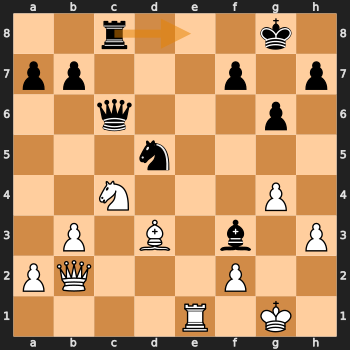

In [26]:
# Render the board just before the top brilliant-move candidate, if any were found.
import chess
import chess.svg
from IPython.display import SVG, display

if not brilliants.empty:
    top = brilliants.sort_values("material_swing", ascending=False).iloc[0]
    board = chess.Board(top["fen_before"])
    move = board.parse_san(top["move"])
    print(f"Game {top['link_id']}, move {top['move_no']} ({top['player']}): {top['move']}"
          f"  (material swing: {top['material_swing']} pawns)")
    display(SVG(chess.svg.board(
        board=board, size=350,
        arrows=[chess.svg.Arrow(move.from_square, move.to_square, color="#e6820080")],
    )))
else:
    print("No brilliant-move candidates found with the current thresholds.")

## 5. Player Style Analysis

Castling habits, piece activity, material dynamics, and a lightweight
aggregate "style profile". These are exploratory heuristics (see the
limitations note in the introduction), not a validated model.

In [27]:
from src.player_profile import castling_stats, king_safety_proxy, first_move_stats

cs = castling_stats(moves_df, games_df)
print(f"Castled kingside:  {cs['kingside_pct']:.1f}%")
print(f"Castled queenside: {cs['queenside_pct']:.1f}%")
print(f"Never castled:     {cs['no_castle_pct']:.1f}%")
print(f"Average castling move: {cs['avg_castle_move']:.1f}")

ks = king_safety_proxy(moves_df)
print(f"\nGames with an early (first 15 plies) non-castling king move: "
      f"{ks['games_with_early_king_move']} ({ks['pct_games_with_early_king_move']:.1f}%)")

print("\nFirst move as White:")
first_move_stats(moves_df)

Castled kingside:  73.3%
Castled queenside: 4.6%
Never castled:     22.1%
Average castling move: 10.5



Games with an early (first 15 plies) non-castling king move: 18 (0.8%)

First move as White:


move
d4    1117
e4      69
d3       2
Name: count, dtype: int64

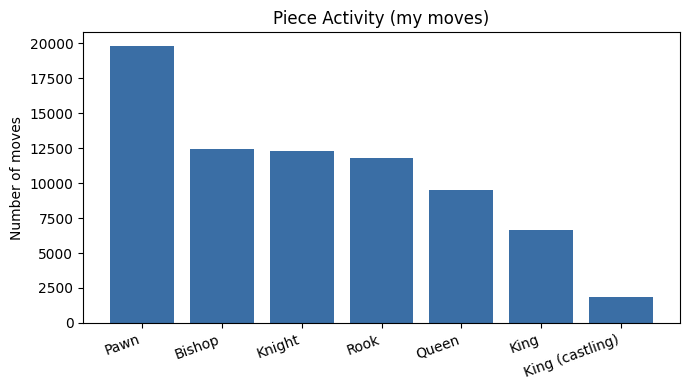

In [28]:
from src.player_profile import piece_activity_stats

activity = piece_activity_stats(moves_df)
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(activity.index, activity.values, color="#3A6EA5")
ax.set_title("Piece Activity (my moves)")
ax.set_ylabel("Number of moves")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

In [29]:
from src.player_profile import queen_trade_stats, material_imbalance_by_phase, pawn_structure_summary

print("Queen trade outcomes:")
print(queen_trade_stats(result_df))

print("\nAverage absolute material imbalance by phase:")
display(material_imbalance_by_phase(result_df))

print("\nPawn structure (sampled from each game's final analyzed position):")
print(pawn_structure_summary(result_df))

Queen trade outcomes:


queens_stayed_on          902
traded                    858
queen_sac_or_imbalance    617
Name: count, dtype: int64

Average absolute material imbalance by phase:


,avg_abs_material_imbalance
phase,
Opening,0.463236
Middlegame,2.759474
Endgame,5.411098



Pawn structure (sampled from each game's final analyzed position):


{'n_games_sampled': 2263, 'avg_doubled_pawn_files': 0.12814847547503314, 'avg_pawn_islands': 2.1060539107379586}


In [30]:
from src.player_profile import endgame_frequency

eg = endgame_frequency(games_df, moves_df)
print(f"Games reaching an endgame (move 30+): {eg['n_reached_endgame']} / {eg['n_games']} "
      f"({eg['endgame_pct']:.1f}%)")

Games reaching an endgame (move 30+): 1165 / 2379 (49.0%)


Detected sacrifices (sound or not): 2500 across 2379 games (~1.05 per game)
  aggression            : 0.53
  tactical_sharpness    : 0.59
  solidity              : 0.52
  endgame_reach         : 0.49
  repertoire_diversity  : 0.71


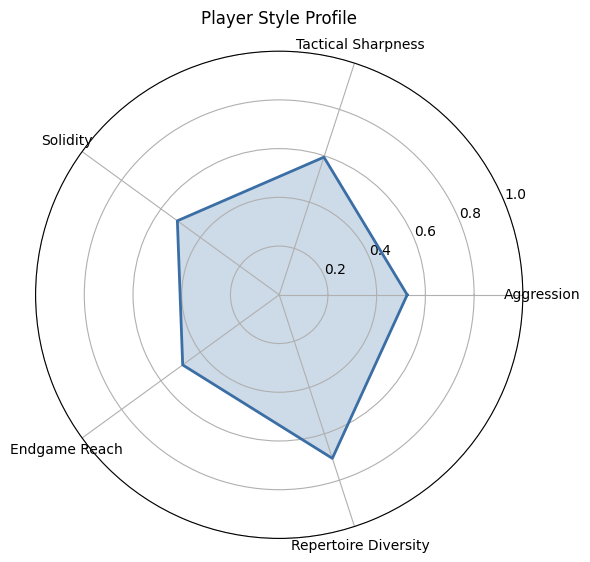

In [31]:
from src.tactics_analysis import find_sacrifices
from src.player_profile import compute_style_profile, plot_style_radar

# Reuse the same sacrifice scan for both the style profile and the raw count below.
sacrifices = find_sacrifices(result_df)
print(f"Detected sacrifices (sound or not): {len(sacrifices)} across {games_df['uuid'].nunique()} games "
      f"(~{len(sacrifices) / games_df['uuid'].nunique():.2f} per game)")

style_profile = compute_style_profile(games_df, moves_df, result_df, sacrifices_df=sacrifices)
for k, v in style_profile.items():
    print(f"  {k:22s}: {v:.2f}")

plot_style_radar(style_profile)

## 6. Advanced Analysis

Performance vs. opponent rating, an "improvement curve" over time, and
clustering games into rough style groups.

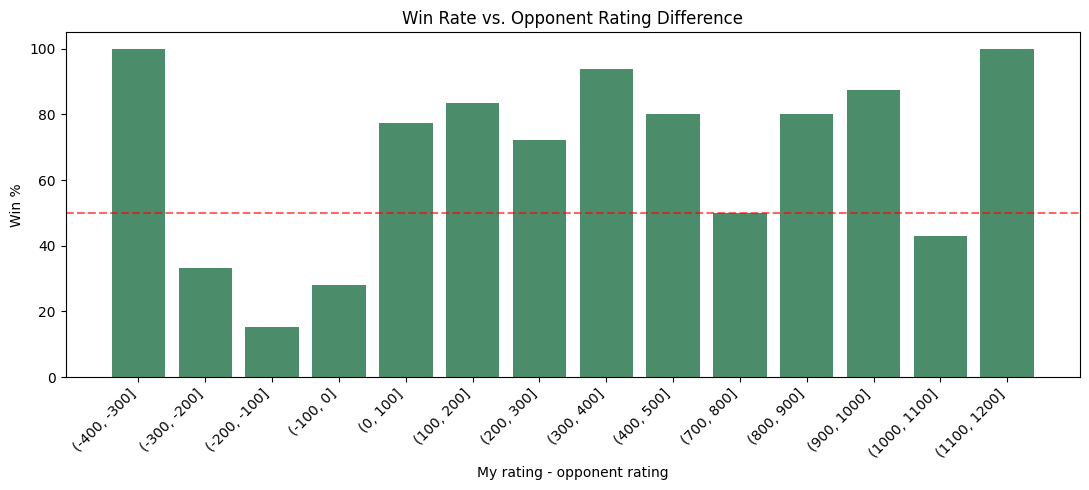

In [32]:
from src.overview_stats import plot_performance_by_opponent_rating

plot_performance_by_opponent_rating(games_df, bin_size=100)

> **Reading this chart**: buckets close to 0 can look more lopsided than
> expected. Since a player's rating changes over time, a game played long ago
> (when the player was rated lower) and a recent game can land in the same
> "rating difference" bucket for very different reasons — this comparison
> doesn't control for the player's own improvement over time.

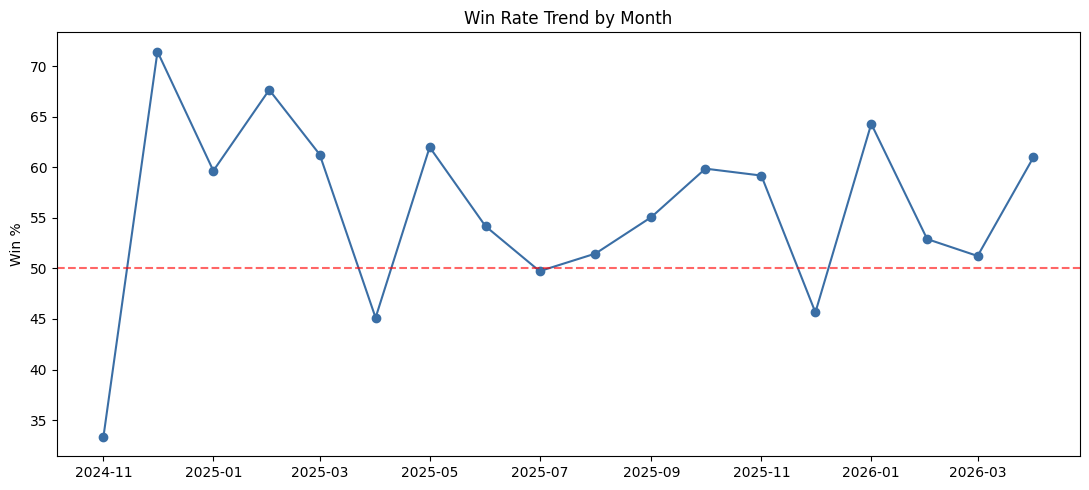

In [33]:
from src.overview_stats import plot_win_rate_trend

plot_win_rate_trend(games_df)

Cluster centroids (average per-game characteristics):


,games,avg_cp_loss,blunder_rate,avg_plies,avg_capture_rate
cluster,,,,,
0,1330,62.902393,0.025523,48.358647,0.271405
1,521,160.386730,0.041760,104.833013,0.239833
2,526,535.173116,0.109302,56.281369,0.272230


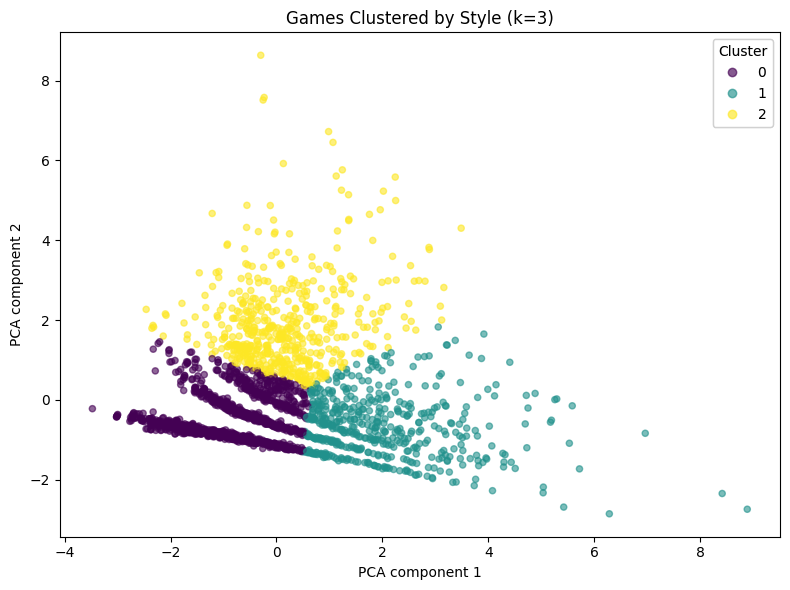

In [34]:
from src.player_profile import cluster_games_by_style, plot_game_clusters

assignments, cluster_summary = cluster_games_by_style(games_df, result_df, moves_df, n_clusters=3)
print("Cluster centroids (average per-game characteristics):")
display(cluster_summary)

plot_game_clusters(games_df, result_df, moves_df, n_clusters=3)

Roughly speaking, clusters with low average centipawn loss and blunder rate
are the player's "clean" games; clusters with high average centipawn loss and
higher blunder rates are rougher, more chaotic games; game length and capture
rate help separate quick tactical fights from longer grinds.

## Conclusion & Limitations Recap

This notebook exercises the full `Chess-Project` pipeline end-to-end: download
→ parse → cached engine analysis → statistics → opening analysis → tactical
analysis → style analysis → clustering.

**Keep in mind while reading the results above:**
- Engine analysis is at a shallow depth (10 ply) for speed; treat evaluations
  as directional, not authoritative.
- "Brilliant move", "sacrifice", and "style profile" detectors are heuristics
  built from the moves actually played — they approximate, rather than prove,
  chess concepts like soundness of a sacrifice or playing style.
- Some charts (accuracy trend, opponent-rating performance) are affected by
  data availability or by the player's own rating changing over time.
- Every module used here (`src/opening_analysis.py`, `src/tactics_analysis.py`,
  `src/player_profile.py`, `src/overview_stats.py`) is reusable directly from
  other notebooks or scripts — this notebook itself stays mostly to function
  calls, per the project's own conventions.